# Intraday Momentum — Signal Research

**Paper:** Zarattini, Aziz & Barbon (2024), "Beat the Market"
**Instrument:** SPY (5-min bars, regular session 9:30–16:00 ET)
**Signal:** Noise area breakout at 30-min checkpoints
**Stop:** Trailing stop = max(upper_bound, VWAP) for longs / min(lower_bound, VWAP) for shorts
**Fast Alpha:** Optional micro-pullback entry/exit on 5-min bars (Zarattini & Pagani, 2026)

This notebook generates raw signal trades — **no position sizing, no equity tracking.**
The `pct_return_gross` is the raw price move, independent of leverage or account size.

Two signal versions are compared:
1. **Baseline** — enter/exit at checkpoint prices
2. **Fast Alpha** — delay entry/exit until 5-min pullback/counter-move

## 1. Setup

In [1]:
import sys
sys.path.insert(0, "../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import time as dt_time
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

from _shared.loaders_data import fetch_historical_data
from _shared.fees import calculate_fees_pct
from _shared.significance import full_significance_report, print_significance_report

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 2. Configuration

In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================

SYMBOL     = "SPY"
INSTRUMENT = "SPY"
START_DATE = "2016-01-01"
END_DATE   = "2026-04-01"

STARTING_CAPITAL = 100_000
STRATEGY_NAME    = "Intraday Momentum"
SAVE_NAME        = "intraday_momentum"

# Paper parameters
LOOKBACK       = 14     # days for noise boundary calculation
VOL_MULTIPLIER = 1.0    # noise area width multiplier (paper uses 1.0)

# Checkpoint times (10:00 to 15:30, every 30 min)
CHECKPOINTS = []
for h in range(10, 16):
    CHECKPOINTS.append(dt_time(h, 0))
    if h < 16:
        CHECKPOINTS.append(dt_time(h, 30))
CHECKPOINTS = [t for t in CHECKPOINTS if t < dt_time(16, 0)]
print(f"Checkpoints: {[str(t)[:5] for t in CHECKPOINTS]}")

Checkpoints: ['10:00', '10:30', '11:00', '11:30', '12:00', '12:30', '13:00', '13:30', '14:00', '14:30', '15:00', '15:30']


## 3. Data Fetching

In [3]:
# =============================================================================
# DATA FETCHING — 5-min bars
# =============================================================================

data_dict = fetch_historical_data([SYMBOL], TimeFrame(5, TimeFrameUnit.Minute), START_DATE, END_DATE)

raw = data_dict[SYMBOL].copy()
if raw.index.tz is None:
    raw.index = raw.index.tz_localize("UTC").tz_convert("US/Eastern")
else:
    raw.index = raw.index.tz_convert("US/Eastern")
raw = raw.reset_index()

# Filter to RTH only (9:30 - 16:00)
raw["time"] = raw["timestamp"].dt.time
raw["date"] = raw["timestamp"].dt.date
raw = raw[(raw["time"] >= dt_time(9, 30)) & (raw["time"] < dt_time(16, 0))].copy()
print(f"5-min RTH bars: {len(raw):,}")

# Compute cumulative VWAP per day from 5-min bars
raw["typical_price"] = (raw["high"] + raw["low"] + raw["close"]) / 3
raw["tp_vol"] = raw["typical_price"] * raw["volume"]

daily_groups = raw.groupby("date")
raw["cum_tp_vol"] = daily_groups["tp_vol"].cumsum()
raw["cum_vol"] = daily_groups["volume"].cumsum()
raw["vwap_calc"] = raw["cum_tp_vol"] / raw["cum_vol"]

print(f"VWAP computed for {raw['date'].nunique()} days")

Fetching SPY...
  472,076 bars
5-min RTH bars: 200,793
VWAP computed for 2575 days


## 4. Build 30-min Checkpoint Bars

In [4]:
# =============================================================================
# BUILD 30-MIN CHECKPOINT BARS WITH VWAP
# =============================================================================

checkpoint_rows = []

for date, day_df in raw.groupby("date"):
    day_df = day_df.sort_values("timestamp")
    if len(day_df) < 20:
        continue

    day_open = day_df["open"].iloc[0]

    for cp_time in CHECKPOINTS:
        mask = day_df["time"] <= cp_time
        bars_up_to = day_df[mask]

        if len(bars_up_to) == 0:
            continue

        exact_mask = day_df["time"] == cp_time
        if exact_mask.any():
            cp_close = day_df[exact_mask]["close"].iloc[-1]
        else:
            cp_close = bars_up_to["close"].iloc[-1]

        cp_high = bars_up_to["high"].max()
        cp_low = bars_up_to["low"].min()
        cp_vwap = bars_up_to["vwap_calc"].iloc[-1]
        move_from_open = abs(cp_close / day_open - 1)

        checkpoint_rows.append({
            "date": pd.Timestamp(date),
            "checkpoint": cp_time,
            "open": day_open,
            "close": cp_close,
            "high_so_far": cp_high,
            "low_so_far": cp_low,
            "vwap": cp_vwap,
            "move_from_open": move_from_open,
        })

checkpoints_df = pd.DataFrame(checkpoint_rows)
print(f"Checkpoint observations: {len(checkpoints_df):,}")
print(f"Days with checkpoints: {checkpoints_df['date'].nunique():,}")
print(f"Avg checkpoints per day: {len(checkpoints_df) / checkpoints_df['date'].nunique():.1f}")

Checkpoint observations: 30,900
Days with checkpoints: 2,575
Avg checkpoints per day: 12.0


## 5. Noise Area Boundaries

For each day *t* and checkpoint time HH:MM:
- σ(t, HH:MM) = avg of |close/open - 1| at HH:MM over last 14 days
- Upper = max(open_t, prev_close) × (1 + VM × σ)
- Lower = min(open_t, prev_close) × (1 − VM × σ)

In [5]:
# =============================================================================
# COMPUTE NOISE AREA BOUNDARIES (time-of-day dependent)
# =============================================================================

# Get previous day's close for gap adjustment
day_last_close = checkpoints_df.groupby("date")["close"].last()
prev_close_map = day_last_close.shift(1)
checkpoints_df["prev_close"] = checkpoints_df["date"].map(prev_close_map)

# Build pivot: rows = dates, columns = checkpoint times, values = move_from_open
pivot = checkpoints_df.pivot_table(index="date", columns="checkpoint",
                                    values="move_from_open", aggfunc="first")

# Rolling 14-day mean for each checkpoint time (shift by 1 to avoid look-ahead)
sigma_pivot = pivot.shift(1).rolling(LOOKBACK, min_periods=LOOKBACK).mean()

# Melt back to long format
sigma_long = sigma_pivot.reset_index().melt(id_vars="date", var_name="checkpoint",
                                             value_name="sigma")

# Merge sigma into checkpoints
checkpoints_df = checkpoints_df.merge(sigma_long, on=["date", "checkpoint"], how="left")

# Compute boundaries with gap adjustment
checkpoints_df["ref_upper"] = checkpoints_df[["open", "prev_close"]].max(axis=1)
checkpoints_df["ref_lower"] = checkpoints_df[["open", "prev_close"]].min(axis=1)

checkpoints_df["upper_bound"] = checkpoints_df["ref_upper"] * (1 + VOL_MULTIPLIER * checkpoints_df["sigma"])
checkpoints_df["lower_bound"] = checkpoints_df["ref_lower"] * (1 - VOL_MULTIPLIER * checkpoints_df["sigma"])

# Drop rows without sigma (warmup period)
valid = checkpoints_df.dropna(subset=["sigma"]).copy()
print(f"Valid checkpoints (after warmup): {len(valid):,}")
print(f"Valid trading days: {valid['date'].nunique():,}")

# Sample
sample_day = valid["date"].unique()[100]
sample = valid[valid["date"] == sample_day][["checkpoint", "open", "close", "sigma",
                                              "upper_bound", "lower_bound", "vwap"]]
print(f"\nSample day ({sample_day.date()}):")
print(sample.to_string(index=False))

Valid checkpoints (after warmup): 30,732
Valid trading days: 2,561

Sample day (2016-06-16):
checkpoint  open  close    sigma  upper_bound  lower_bound       vwap
  10:00:00 176.3 175.52 0.001576   178.210359   176.022210 175.895526
  10:30:00 176.3 175.47 0.001707   178.233706   175.999076 175.777382
  11:00:00 176.3 175.88 0.001909   178.269733   175.963380 175.739468
  11:30:00 176.3 176.25 0.001707   178.233803   175.998981 175.806801
  12:00:00 176.3 176.01 0.001724   178.236663   175.996146 175.836545
  12:30:00 176.3 176.58 0.001570   178.209303   176.023256 175.932027
  13:00:00 176.3 177.00 0.001858   178.260571   175.972457 176.061396
  13:30:00 176.3 176.71 0.001901   178.268228   175.964870 176.152611
  14:00:00 176.3 176.87 0.002417   178.360084   175.873856 176.199169
  14:30:00 176.3 177.07 0.002494   178.373737   175.860328 176.266880
  15:00:00 176.3 177.31 0.002866   178.439939   175.794732 176.349619
  15:30:00 176.3 177.76 0.002447   178.365313   175.868675 176.4673

## 6. Fast Alpha Helpers

Micro-pullback entry/exit on 5-min bars. After a breakout is detected on
30-min checkpoints, delay entry until a 5-min bar moves in the opposite
direction (buy the dip / sell the rip). Same logic for exits.

In [6]:
# =============================================================================
# PREPARE 5-MIN BAR RETURNS FOR FAST ALPHA OVERLAY
# =============================================================================

five_min_returns = {}

for date, day_df in raw.groupby("date"):
    day_df = day_df.sort_values("timestamp")
    if len(day_df) < 20:
        continue

    bars = day_df[["time", "close"]].copy()
    bars["ret"] = bars["close"].pct_change()
    bars = bars.dropna()

    five_min_returns[pd.Timestamp(date)] = bars[["time", "close", "ret"]].reset_index(drop=True)

print(f"Days with 5-min returns: {len(five_min_returns):,}")


def find_pullback_price(day_bars, after_time, direction, max_wait_bars=6):
    """
    Find the close price of the first 5-min bar that moves opposite to direction.

    Parameters
    ----------
    day_bars : DataFrame with columns [time, close, ret]
    after_time : time object — look for pullback after this checkpoint
    direction : 'long' or 'short' — the position we want to enter
    max_wait_bars : int — max 5-min bars to wait (default 6 = 30 min)

    Returns
    -------
    (pullback_price, pullback_time) or (None, None) if no pullback found
    """
    future = day_bars[day_bars["time"] > after_time]

    if len(future) == 0:
        return None, None

    for idx in range(min(max_wait_bars, len(future))):
        bar = future.iloc[idx]

        if direction == "long" and bar["ret"] < 0:
            return bar["close"], bar["time"]
        elif direction == "short" and bar["ret"] > 0:
            return bar["close"], bar["time"]

    return None, None


def find_exit_pullback_price(day_bars, after_time, position, max_wait_bars=6):
    """
    Find improved exit price by waiting for a counter-move.

    For long exit: wait for an UP bar before selling.
    For short exit: wait for a DOWN bar before covering.
    """
    future = day_bars[day_bars["time"] > after_time]

    if len(future) == 0:
        return None, None

    for idx in range(min(max_wait_bars, len(future))):
        bar = future.iloc[idx]

        if position == "long" and bar["ret"] > 0:
            return bar["close"], bar["time"]
        elif position == "short" and bar["ret"] < 0:
            return bar["close"], bar["time"]

    return None, None

print("Fast alpha helper functions loaded.")

Days with 5-min returns: 2,575
Fast alpha helper functions loaded.


## 7. Signal Generation

Generates raw trades — **no position sizing, no equity tracking.**
The `pct_return_gross` is the raw price move, independent of leverage or account size.

Runs both baseline and fast alpha versions from a single function.

In [7]:
def generate_signals(valid_checkpoints, five_min_data, use_fast_alpha=False, max_wait_bars=6):
    """
    Generate raw intraday momentum trades — signal only, no sizing.

    Parameters
    ----------
    valid_checkpoints : DataFrame — checkpoint bars with noise boundaries
    five_min_data : dict — {date: DataFrame} of 5-min bars for fast alpha
    use_fast_alpha : bool — if True, apply micro-pullback entry/exit
    max_wait_bars : int — max 5-min bars to wait for pullback

    Returns
    -------
    DataFrame with standardized columns:
        entry_time, exit_time, direction, instrument, entry_price, exit_price,
        pct_return_gross, exit_reason, stop_price
    """
    trades = []
    trading_days = sorted(valid_checkpoints["date"].unique())

    for day in trading_days:
        day_data = valid_checkpoints[valid_checkpoints["date"] == day].sort_values("checkpoint")

        if len(day_data) < 3:
            continue

        day_5min = five_min_data.get(day, None)

        position = None
        entry_price = None
        entry_time = None
        last_stop = None

        for _, cp in day_data.iterrows():
            cp_price = cp["close"]
            cp_time = cp["checkpoint"]
            upper = cp["upper_bound"]
            lower = cp["lower_bound"]
            vwap = cp["vwap"]

            if position is None:
                # ── Check for entry ──
                signal = None
                if cp_price > upper:
                    signal = "long"
                elif cp_price < lower:
                    signal = "short"

                if signal is not None:
                    actual_entry_price = cp_price
                    actual_entry_time = cp_time

                    if use_fast_alpha and day_5min is not None:
                        pb_price, pb_time = find_pullback_price(
                            day_5min, cp_time, signal, max_wait_bars
                        )
                        if pb_price is not None:
                            actual_entry_price = pb_price
                            actual_entry_time = pb_time

                    position = signal
                    entry_price = actual_entry_price
                    entry_time = actual_entry_time
                    # Store initial stop for standardized output
                    if signal == "long":
                        last_stop = max(upper, vwap)
                    else:
                        last_stop = min(lower, vwap)
            else:
                # ── Check trailing stop ──
                should_close = False

                if position == "long":
                    trail_stop = max(upper, vwap)
                    last_stop = trail_stop
                    if cp_price < trail_stop:
                        should_close = True
                elif position == "short":
                    trail_stop = min(lower, vwap)
                    last_stop = trail_stop
                    if cp_price > trail_stop:
                        should_close = True

                if should_close:
                    actual_exit_price = cp_price
                    actual_exit_time = cp_time

                    if use_fast_alpha and day_5min is not None:
                        ex_price, ex_time = find_exit_pullback_price(
                            day_5min, cp_time, position, max_wait_bars
                        )
                        if ex_price is not None:
                            actual_exit_price = ex_price
                            actual_exit_time = ex_time

                    if position == "long":
                        pct_ret = (actual_exit_price - entry_price) / entry_price
                    else:
                        pct_ret = (entry_price - actual_exit_price) / entry_price

                    trades.append({
                        "entry_time": pd.Timestamp.combine(day, entry_time),
                        "exit_time": pd.Timestamp.combine(day, actual_exit_time),
                        "direction": position,
                        "instrument": INSTRUMENT,
                        "entry_price": round(entry_price, 4),
                        "exit_price": round(actual_exit_price, 4),
                        "pct_return_gross": round(pct_ret, 6),
                        "exit_reason": "trail_stop",
                        "stop_price": round(last_stop, 4),
                    })

                    # Check for reversal
                    if position == "long" and cp_price < lower:
                        rev_entry = cp_price
                        rev_time = cp_time
                        if use_fast_alpha and day_5min is not None:
                            pb_p, pb_t = find_pullback_price(day_5min, cp_time, "short", max_wait_bars)
                            if pb_p is not None:
                                rev_entry = pb_p
                                rev_time = pb_t
                        position = "short"
                        entry_price = rev_entry
                        entry_time = rev_time
                        last_stop = min(lower, vwap)
                    elif position == "short" and cp_price > upper:
                        rev_entry = cp_price
                        rev_time = cp_time
                        if use_fast_alpha and day_5min is not None:
                            pb_p, pb_t = find_pullback_price(day_5min, cp_time, "long", max_wait_bars)
                            if pb_p is not None:
                                rev_entry = pb_p
                                rev_time = pb_t
                        position = "long"
                        entry_price = rev_entry
                        entry_time = rev_time
                        last_stop = max(upper, vwap)
                    else:
                        position = None
                        entry_price = None

        # ── Close at EOD ──
        if position is not None:
            eod_price = day_data["close"].iloc[-1]

            if position == "long":
                pct_ret = (eod_price - entry_price) / entry_price
            else:
                pct_ret = (entry_price - eod_price) / entry_price

            trades.append({
                "entry_time": pd.Timestamp.combine(day, entry_time),
                "exit_time": pd.Timestamp.combine(day, dt_time(16, 0)),
                "direction": position,
                "instrument": INSTRUMENT,
                "entry_price": round(entry_price, 4),
                "exit_price": round(eod_price, 4),
                "pct_return_gross": round(pct_ret, 6),
                "exit_reason": "eod",
                "stop_price": round(last_stop, 4) if last_stop else np.nan,
            })

    return pd.DataFrame(trades)

print("generate_signals() defined.")

generate_signals() defined.


## 8. Signal Generation & Baseline vs Fast Alpha Comparison

Run both versions, compare signal quality, then pick the winner for significance testing.

In [8]:
# ── Generate signals ──
print("Running BASELINE signals...")
trades_base = generate_signals(valid, five_min_returns, use_fast_alpha=False)
print(f"  Trades: {len(trades_base):,}")

print("\nRunning FAST ALPHA signals...")
trades_fa = generate_signals(valid, five_min_returns, use_fast_alpha=True, max_wait_bars=6)
print(f"  Trades: {len(trades_fa):,}")

# ── Compare gross signal quality ──
def signal_summary(trades, label):
    rets = trades["pct_return_gross"]
    sharpe = rets.mean() / rets.std() * np.sqrt(252) if rets.std() > 0 else 0
    total = (1 + rets).prod() - 1
    wins = (rets > 0).mean() * 100
    avg_w = rets[rets > 0].mean() * 100
    avg_l = rets[rets < 0].mean() * 100
    pf = abs(rets[rets > 0].sum() / rets[rets < 0].sum()) if rets[rets < 0].sum() != 0 else np.inf
    print(f"  {label:<16} Trades={len(trades):>5}, Sharpe={sharpe:>6.2f}, "
          f"Total={total*100:>8.2f}%, WR={wins:>5.1f}%, PF={pf:>5.2f}, "
          f"AvgW={avg_w:>5.2f}%, AvgL={avg_l:>6.2f}%")
    return sharpe

print("\nSIGNAL QUALITY (gross, no sizing):")
s_base = signal_summary(trades_base, "Baseline")
s_fa = signal_summary(trades_fa, "Fast Alpha")

print(f"\nFast Alpha improvement: Sharpe {s_fa - s_base:+.2f}")

# Long/Short breakdown
for label, tr in [("Baseline", trades_base), ("Fast Alpha", trades_fa)]:
    print(f"\n{label}:")
    for side in ["long", "short"]:
        sub = tr[tr["direction"] == side]
        wr = (sub["pct_return_gross"] > 0).mean() * 100
        avg = sub["pct_return_gross"].mean() * 100
        print(f"  {side}: {len(sub)} trades, WR={wr:.1f}%, avg={avg:.4f}%")

Running BASELINE signals...
  Trades: 2,304

Running FAST ALPHA signals...
  Trades: 2,304

SIGNAL QUALITY (gross, no sizing):
  Baseline         Trades= 2304, Sharpe=  0.62, Total=   44.74%, WR= 37.5%, PF= 1.14, AvgW= 0.36%, AvgL= -0.21%
  Fast Alpha       Trades= 2304, Sharpe=  1.36, Total=  132.97%, WR= 46.2%, PF= 1.36, AvgW= 0.31%, AvgL= -0.20%

Fast Alpha improvement: Sharpe +0.74

Baseline:
  long: 1181 trades, WR=42.1%, avg=0.0279%
  short: 1123 trades, WR=32.6%, avg=0.0055%

Fast Alpha:
  long: 1181 trades, WR=50.1%, avg=0.0428%
  short: 1123 trades, WR=42.0%, avg=0.0322%


## 9. Significance Testing

In [9]:
# Use Fast Alpha as the primary signal (based on results above)
raw_trades = trades_fa.copy()

# Net returns (no sizing needed)
raw_trades["fee_pct"] = raw_trades.apply(
    lambda t: calculate_fees_pct(t["entry_price"], t["exit_price"], t["direction"]), axis=1)
raw_trades["pct_return_net"] = raw_trades["pct_return_gross"] - raw_trades["fee_pct"]

print(f"Avg fee: {raw_trades['fee_pct'].mean()*100:.4f}% per trade")
print(f"Avg gross return: {raw_trades['pct_return_gross'].mean()*100:.4f}%")
print(f"Avg net return: {raw_trades['pct_return_net'].mean()*100:.4f}%")

# Significance: GROSS
sig_gross = raw_trades[["direction", "pct_return_gross"]].copy()
sig_gross["net_pnl"] = sig_gross["pct_return_gross"]
sig_gross["equity_before"] = 1.0
sig_gross["position"] = sig_gross["direction"]

if len(sig_gross) >= 5:
    report_gross = full_significance_report(sig_gross, strategy_name=f"{STRATEGY_NAME} (gross)")
    print_significance_report(report_gross)

# Significance: NET
sig_net = raw_trades[["direction", "pct_return_net"]].copy()
sig_net["net_pnl"] = sig_net["pct_return_net"]
sig_net["equity_before"] = 1.0
sig_net["position"] = sig_net["direction"]

if len(sig_net) >= 5:
    report_net = full_significance_report(sig_net, strategy_name=f"{STRATEGY_NAME} (net)")
    print_significance_report(report_net)

Avg fee: 0.0093% per trade
Avg gross return: 0.0377%
Avg net return: 0.0284%

STATISTICAL SIGNIFICANCE — Intraday Momentum (gross)

1. t-test (returns > 0)
   Mean return:  0.0377% per trade
   t-statistic:  4.1122
   p-value:      2e-05
   Significant:  YES

2. Bootstrap Sharpe (95% CI)
   Observed Sharpe:   1.3603
   95% CI:            [0.7545, 1.9676]
   % below zero:      0.0%
   Significant:       YES

3. Permutation test (random signs)
   Observed Sharpe:   1.3603
   p-value:           0.0
   Significant:       YES

──────────────────────────────────────────────────────────────────────
VERDICT: SIGNIFICANT (strong) (3/3 tests pass)

STATISTICAL SIGNIFICANCE — Intraday Momentum (net)

1. t-test (returns > 0)
   Mean return:  0.0284% per trade
   t-statistic:  3.0968
   p-value:      0.00099
   Significant:  YES

2. Bootstrap Sharpe (95% CI)
   Observed Sharpe:   1.0244
   95% CI:            [0.4101, 1.63]
   % below zero:      0.04%
   Significant:       YES

3. Permutation test (

## 10. Simple Equity Curve — Gross vs Net

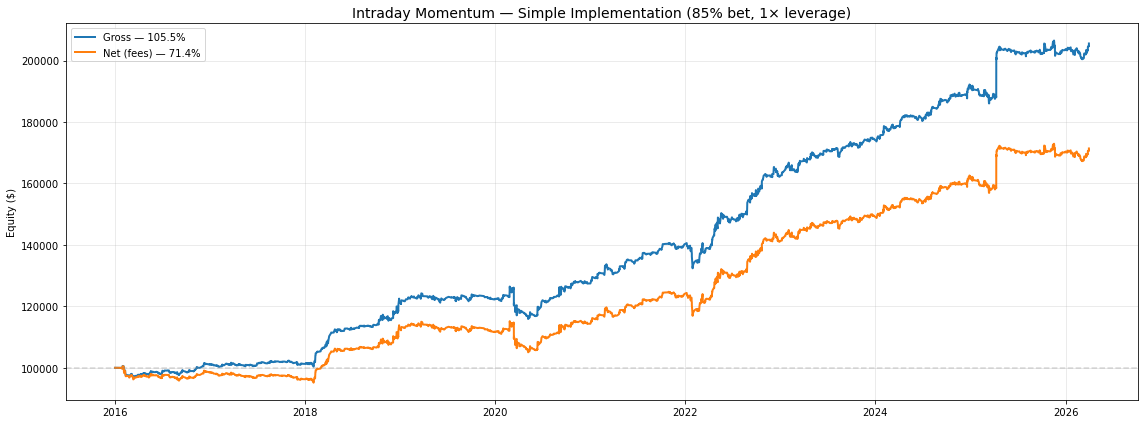

Fee drag: $34,163 (16.6% of gross)


In [10]:
BET_SIZE = 0.85

equity_gross = STARTING_CAPITAL
equity_net = STARTING_CAPITAL
gross_curve = [STARTING_CAPITAL]
net_curve = [STARTING_CAPITAL]

for _, trade in raw_trades.iterrows():
    notional_g = equity_gross * BET_SIZE
    notional_n = equity_net * BET_SIZE
    shares_g = int(notional_g / trade["entry_price"])
    shares_n = int(notional_n / trade["entry_price"])

    if trade["direction"] == "long":
        pnl_g = shares_g * (trade["exit_price"] - trade["entry_price"])
        pnl_n = shares_n * (trade["exit_price"] - trade["entry_price"])
    else:
        pnl_g = shares_g * (trade["entry_price"] - trade["exit_price"])
        pnl_n = shares_n * (trade["entry_price"] - trade["exit_price"])

    from _shared.fees import calculate_fees
    fees = calculate_fees(shares_n, trade["entry_price"], trade["exit_price"], trade["direction"])

    equity_gross += pnl_g
    equity_net += pnl_n - fees
    gross_curve.append(equity_gross)
    net_curve.append(equity_net)

dates = [pd.Timestamp(START_DATE)] + pd.to_datetime(raw_trades["exit_time"]).tolist()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(dates, gross_curve, linewidth=2, label=f"Gross — {(gross_curve[-1]/STARTING_CAPITAL-1)*100:.1f}%")
ax.plot(dates, net_curve, linewidth=2, label=f"Net (fees) — {(net_curve[-1]/STARTING_CAPITAL-1)*100:.1f}%")
ax.axhline(STARTING_CAPITAL, color="gray", linestyle="--", alpha=0.3)
ax.set_title(f"{STRATEGY_NAME} — Simple Implementation ({BET_SIZE:.0%} bet, 1× leverage)", fontsize=14)
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylabel("Equity ($)")
plt.tight_layout(); plt.show()

print(f"Fee drag: ${gross_curve[-1] - net_curve[-1]:,.0f} ({(1 - net_curve[-1]/gross_curve[-1])*100:.1f}% of gross)")

## 12. Save Standardized Trades

Saves raw signal trades for PM consumption. No sizing, no fees baked in.
Run `Intraday_Momentum_Implementation.ipynb` to compare sizing methods.

In [11]:
import os, json

os.makedirs("results", exist_ok=True)

# Standard trades CSV
std_cols = ["entry_time", "exit_time", "direction", "instrument",
            "entry_price", "exit_price", "pct_return_gross", "exit_reason", "stop_price"]
raw_trades[std_cols].to_csv("results/intraday_momentum_trades.csv", index=False)
print(f"Saved {len(raw_trades)} standardized trades → results/intraday_momentum_trades.csv")

# Also save SPY daily prices for implementation notebook
daily_prices = checkpoints_df.groupby("date").agg(
    day_open=("open", "first"),
    day_close=("close", "last"),
).reset_index()
daily_prices.to_csv("results/spy_daily_prices.csv", index=False)
print(f"Saved {len(daily_prices)} daily prices → results/spy_daily_prices.csv")
# Summary JSON
summary = {
    "strategy":    STRATEGY_NAME,
    "instrument":  INSTRUMENT,
    "portfolio":   "short_term",
    "period":      f"{START_DATE} → {END_DATE}",
    "params": {
        "lookback": LOOKBACK,
        "vol_multiplier": VOL_MULTIPLIER,
        "fast_alpha": True,
        "max_wait_bars": 6,
    },
    "trades":      len(raw_trades),
    "significance": {
        "gross": {"sharpe": report_gross["bootstrap"]["observed_sharpe"],
                  "verdict": report_gross["verdict"],
                  "tests_passed": report_gross["tests_passed"]},
        "net":   {"sharpe": report_net["bootstrap"]["observed_sharpe"],
                  "verdict": report_net["verdict"],
                  "tests_passed": report_net["tests_passed"]},
    },
}
with open("results/intraday_momentum_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(f"Saved summary → results/intraday_momentum_summary.json")

print(f"\nNext: run Intraday_Momentum_Implementation.ipynb for sizing comparison")

Saved 2304 standardized trades → results/intraday_momentum_trades.csv
Saved 2575 daily prices → results/spy_daily_prices.csv
Saved summary → results/intraday_momentum_summary.json

Next: run Intraday_Momentum_Implementation.ipynb for sizing comparison
